In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [68]:
import os
import sys
import itertools as it
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import matplotlib as mpl
import seaborn as sns

import cogwheel.cosmology
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from helpers import load_event_data_and_posterior_samples, plot_posterior_samples, get_pII_median_span, expected_lnB

### injection results: $\ln\mathcal B/\rho^2$ vs. $\iota$

In [70]:
# load injection results
mchirp = 30.    # Msun

# construct the grid
iotas = np.arange(0., 0.51, 0.1) * np.pi
qs = np.arange(0.1, 1.01, 0.1)

seed = 12
prior_class = 'IntrinsicLVCPrior'

# load our posterior samples and the released samples from the LVK PE
resdir = f'/home/abbye.williams/GWPE/data/pe_runs_lensing/injections/iota_q_grid/mchirp-{mchirp:.2f}/{prior_class}'

# Bayes factor
n_resamples = 1000  # number of resamples for Bayes factor bootstrap
lnBayes = {}
exp_lnBayes = {}
recovered_iotas = {}
hh = {
    'hh' : {},
    'hh_hm' : {},
    'hh3' : {}
}
# labels for plotting
hh_labels = {
    'hh' : r'$\langle h\vert h\rangle\approx\rho^2$',
    'hh_hm' : r'$\langle h\vert h\rangle\approx\rho^2$ ($m\neq 2$)',
    'hh3' : r'$\langle h_3\vert h_3\rangle\approx\rho_{33}^2$'
}

for (iota, q) in it.product(iotas, qs):

    # event file
    eventname = f'GW{seed}_iota-{iota / np.pi:.2f}_q-{q:.2f}'
    event_path = os.path.join(resdir, eventname)

    # load event data
    event_data, samples = load_event_data_and_posterior_samples(event_path, eventname)

    # get the hh inner product (SNR) from the injection dictionary
    init_dict = event_data.get_init_dict()
    injection = init_dict['injection']
    hh['hh'][(iota, q)] = injection['h_h']

    # load the hh for higher modes (that we computed and saved separately)
    try:
        hh['hh_hm'][(iota, q)] = np.load(os.path.join(event_path, 'run_0', 'hh_hm.npy'), allow_pickle=True).item()[(iota, q)]
        hh['hh3'][(iota, q)] = np.load(os.path.join(event_path, 'run_0', 'hh3.npy'), allow_pickle=True).item()[(iota, q)]
    except FileNotFoundError:
        hh['hh_hm'][(iota, q)] = np.load(os.path.join(resdir, eventname, 'run_1', 'hh_hm.npy'), allow_pickle=True).item()[(iota, q)]
        hh['hh3'][(iota, q)] = np.load(os.path.join(resdir, eventname, 'run_1', 'hh3.npy'), allow_pickle=True).item()[(iota, q)]

    # and the median of the iota distribution
    recovered_iotas[(iota, q)] = np.median(samples['iota'])

    # Bayes factor
    bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
    # log these
    lnbayes_factors = np.log(bayes_factors)
    # get the median and standard deviation
    lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
    lnBayes[(iota, q)] = (lnbayes, lnbayes_std)

    # expected Bayes factor
    # antenna response functions
    par_dic = injection['par_dic']
    fplus, fcross = cogwheel.gw_utils.fplus_fcross(init_dict['detector_names'],
                                                    par_dic['ra'], par_dic['dec'], par_dic['psi'],
                                                    init_dict['tgps'])
    # sum SNR^2 over all detectors
    total_rhosq = np.sum(injection['h_h'])
    mu = np.cos(par_dic['iota'])
    exp_lnBayes[(iota, q)] = expected_lnB(total_rhosq, fplus, fcross, mu)

loaded posterior samples for GW12_iota-0.00_q-0.10 run 0
loaded posterior samples for GW12_iota-0.00_q-0.20 run 0
loaded posterior samples for GW12_iota-0.00_q-0.30 run 0
loaded posterior samples for GW12_iota-0.00_q-0.40 run 0
loaded posterior samples for GW12_iota-0.00_q-0.50 run 0
loaded posterior samples for GW12_iota-0.00_q-0.60 run 0
loaded posterior samples for GW12_iota-0.00_q-0.70 run 0
loaded posterior samples for GW12_iota-0.00_q-0.80 run 1
loaded posterior samples for GW12_iota-0.00_q-0.90 run 0
loaded posterior samples for GW12_iota-0.00_q-1.00 run 0
loaded posterior samples for GW12_iota-0.10_q-0.10 run 0
loaded posterior samples for GW12_iota-0.10_q-0.20 run 0
loaded posterior samples for GW12_iota-0.10_q-0.30 run 0
loaded posterior samples for GW12_iota-0.10_q-0.40 run 0
loaded posterior samples for GW12_iota-0.10_q-0.50 run 0
loaded posterior samples for GW12_iota-0.10_q-0.60 run 1
loaded posterior samples for GW12_iota-0.10_q-0.70 run 0
loaded posterior samples for GW

In [71]:
# reformat the dictionaries into arrays
lnBayes_grid = np.full((len(iotas), len(qs)), np.nan)
exp_lnBayes_grid = np.full_like(lnBayes_grid, np.nan)
recovered_iotas_grid = np.full_like(lnBayes_grid, np.nan)
total_hh_grids = {}
for key in hh.keys():
    total_hh_grids[key] = np.full_like(lnBayes_grid, np.nan)
for i, iota in enumerate(iotas):
    for j, q in enumerate(qs):
        lnBayes_grid[i,j] = lnBayes[(iota, q)][0]
        exp_lnBayes_grid[i,j] = exp_lnBayes[(iota, q)]
        recovered_iotas_grid[i,j] = recovered_iotas[(iota, q)]
        for key, grid in total_hh_grids.items():
            grid[i,j] = np.sum(hh[key][(iota, q)])  # we want the sum of all three detectors
# construct iota and q grids of the same shape
iota_grid = np.repeat(iotas, len(qs))
q_grid = np.tile(qs, len(iotas))

In [78]:
# construct the color maps for the plot
colors = {
    'iota' : iota_grid,
    'q' : q_grid,
    'lnB' : lnBayes_grid.flatten(),
    'snr' : np.sqrt(total_hh_grids['hh_hm'] / total_hh_grids['hh']).flatten()
}
cmap_strs = {
    'iota' : 'flare',
    'q' : 'crest',
    'lnB' : 'Blues',
    'snr' : 'Purples'
}
cmap_labels = {
    'iota' : r'Injected inclination $\iota$',
    'q' : r'Injected mass ratio $q$',
    'lnB' : r'log Bayes factor $\ln\mathcal B$',
    'snr' : r'Relative higher mode SNR $\rho_{m\neq 2}/\rho$'
}
# flag for the detected Type II lensing
det_threshold = 2.
det_flag = (lnBayes_grid >= det_threshold).flatten()

iotas_wrapped = np.array([
    np.min([iota, np.pi - iota]) for iota in recovered_iotas_grid.flatten()
])
rhosq = total_hh_grids['hh'].flatten()

labelsize = 12

# inclination ticks
xticks = np.arange(0., 0.51, 0.1) * np.pi
xtick_labels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]

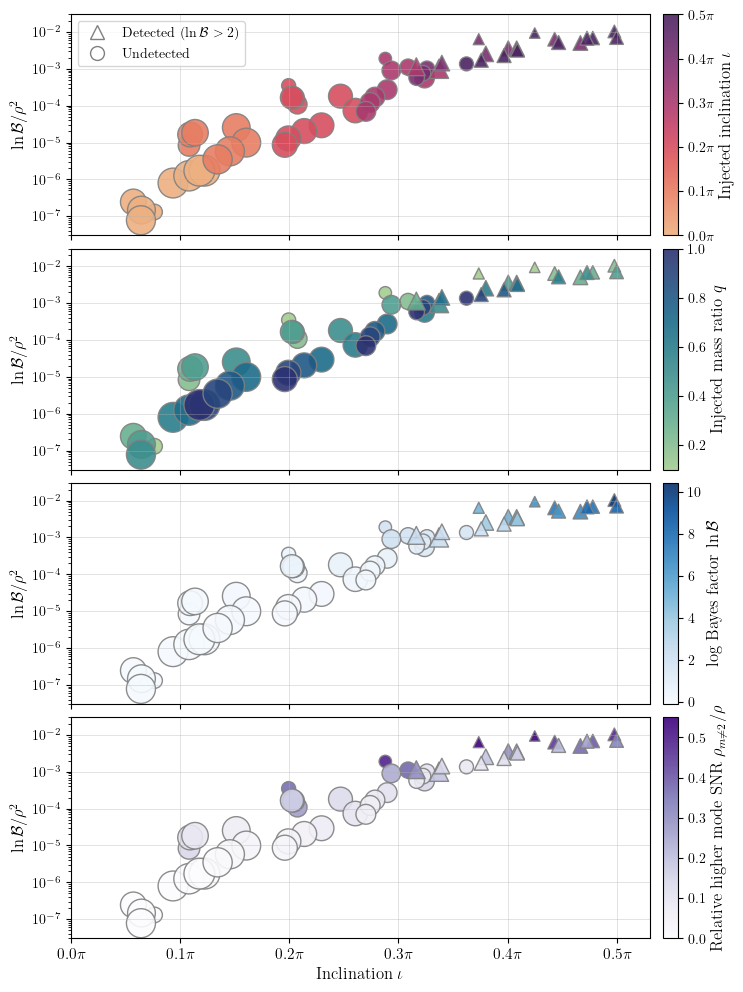

In [ ]:
# plot this curve
fig, axs = plt.subplots(4, 1, figsize=(9,12), gridspec_kw={'hspace' : 0.06})

for ax, key in zip(axs, colors.keys()):
    if key == 'snr':
        vmin, vmax = 0., 0.55
    else:
        vmin, vmax = min(colors[key]), max(colors[key])
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = sns.color_palette(cmap_strs[key], as_cmap=True)
    for m, idx in zip(['o', '^'], [~det_flag, det_flag]):
        im = ax.scatter(iotas_wrapped[idx], np.array(lnBayes_grid.flatten() / rhosq)[idx], marker=m, ec='grey',
                    c=colors[key][idx], cmap=cmap, norm=norm, alpha=0.9, s=rhosq[idx] / 12,
                    label=f'sample at top {cweight * 100:.0f}'r'\% of $|\cos\iota|$')
    cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=15)
    cbar.set_label(cmap_labels[key], size=labelsize)
    if key == 'iota':
        cbar.ax.set_yticks(xticks)
        cbar.ax.set_yticklabels(xtick_labels)

kwargs = dict(ls='None', color='w', markeredgecolor='grey', markersize=10)
det_handle = mpl.lines.Line2D([0], [0], marker='^', label=r'Detected ($\ln\mathcal{B}>2$)', **kwargs)
undet_handle = mpl.lines.Line2D([0], [0], marker='o', label='Undetected', **kwargs)
custom_handles = [det_handle, undet_handle]

for ax in axs:
    ax.set_xticks(xticks)
    ax.set_xticklabels([])
    ax.axhline(0., c='k', alpha=0.5, lw=0.5)
    ax.set_xlim(0., 0.53 * np.pi)
    ax.set_ylim(3e-8, 3e-2)
    ax.grid(alpha=0.5, lw=0.5)
    ax.semilogy()
    ax.set_ylabel(r'$\ln\mathcal{B} / \rho^2$', fontsize=labelsize)
ax.set_xticklabels(xtick_labels, fontsize=11)
ax.set_xlabel(r'Inclination $\iota$', fontsize=labelsize)
axs[0].legend(handles=custom_handles, loc=2)

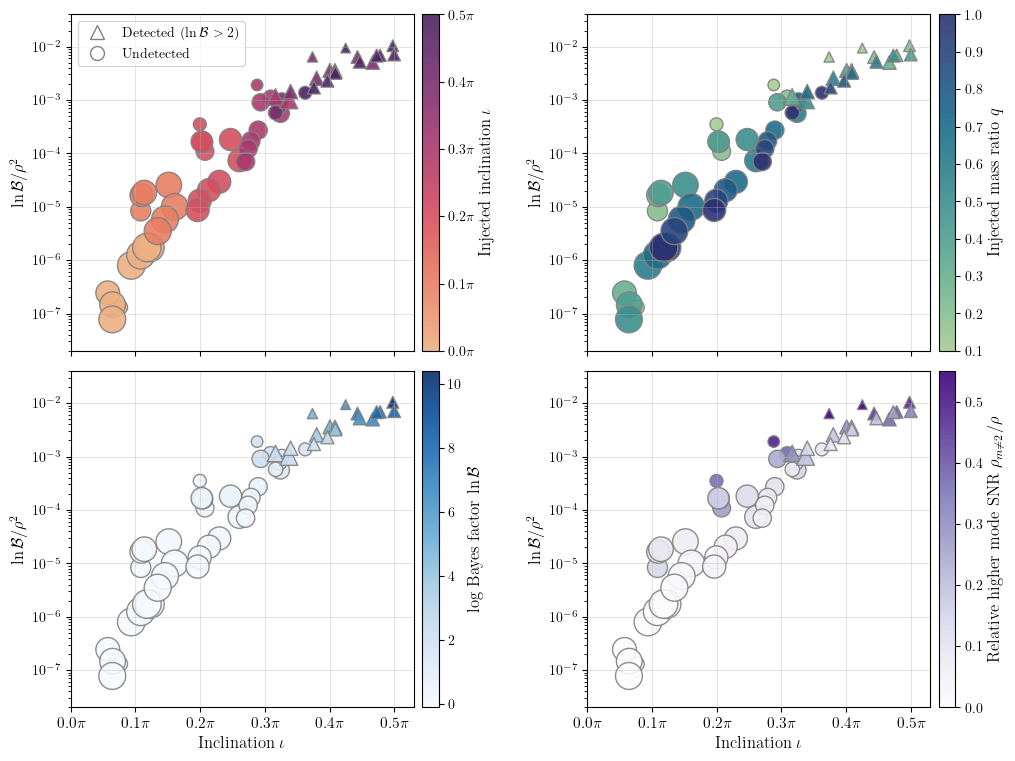

In [80]:
# plot this curve
fig, axs = plt.subplots(2, 2, figsize=(12,9), gridspec_kw={'hspace' : 0.06, 'wspace' : 0.25})

for ax, key in zip(axs.flatten(), colors.keys()):
    if key == 'snr':
        vmin, vmax = 0., 0.55
    else:
        vmin, vmax = min(colors[key]), max(colors[key])
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = sns.color_palette(cmap_strs[key], as_cmap=True)
    for m, idx in zip(['o', '^'], [~det_flag, det_flag]):
        im = ax.scatter(iotas_wrapped[idx], np.array(lnBayes_grid.flatten() / rhosq)[idx], marker=m, ec='grey',
                    c=colors[key][idx], cmap=cmap, norm=norm, alpha=0.9, s=rhosq[idx] / 14,
                    label=f'sample at top {cweight * 100:.0f}'r'\% of $|\cos\iota|$')
    cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=20)
    cbar.set_label(cmap_labels[key], size=labelsize)
    if key == 'iota':
        cbar.ax.set_yticks(xticks)
        cbar.ax.set_yticklabels(xtick_labels)

kwargs = dict(ls='None', color='w', markeredgecolor='grey', markersize=10)
det_handle = mpl.lines.Line2D([0], [0], marker='^', label=r'Detected ($\ln\mathcal{B}>2$)', **kwargs)
undet_handle = mpl.lines.Line2D([0], [0], marker='o', label='Undetected', **kwargs)
custom_handles = [det_handle, undet_handle]

for ax in axs.flatten():
    ax.set_xticks(xticks)
    ax.set_xticklabels([])
    ax.axhline(0., c='k', alpha=0.5, lw=0.5)
    ax.set_xlim(0., 0.53 * np.pi)
    ax.set_ylim(2e-8, 4e-2)
    ax.grid(alpha=0.5, lw=0.5)
    ax.semilogy()
    ax.set_ylabel(r'$\ln\mathcal{B} / \rho^2$', fontsize=labelsize)
# for irow in [0,1]:
#     axs[irow,0].set_ylabel(r'$\ln\mathcal{B} / \rho^2$', fontsize=12)
for icol in [0,1]:
    axs[1,icol].set_xticklabels(xtick_labels, fontsize=11)
    axs[1,icol].set_xlabel(r'Inclination $\iota$', fontsize=labelsize)
axs[0,0].legend(handles=custom_handles, loc=2)